# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4457s 26us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

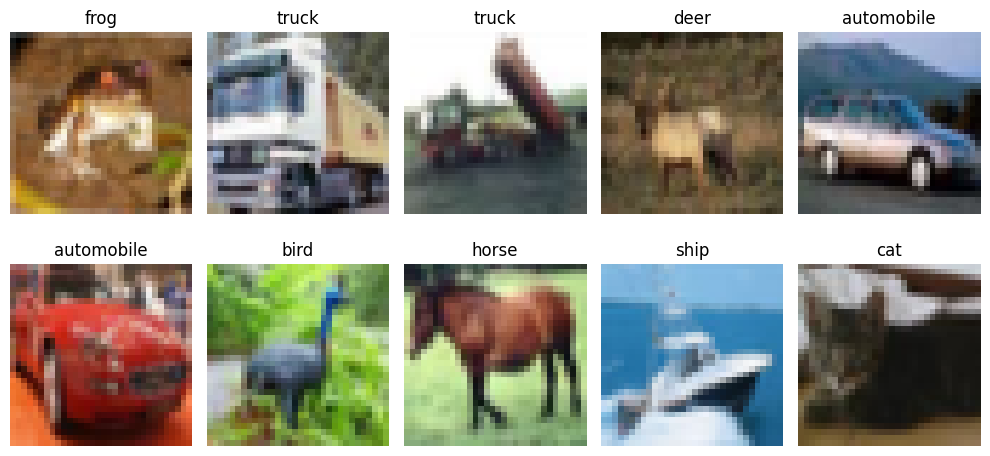

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.2634 - loss: 2.0026 - val_accuracy: 0.3332 - val_loss: 1.8539
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 27ms/step - accuracy: 0.3155 - loss: 1.8730 - val_accuracy: 0.3658 - val_loss: 1.7823
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.3355 - loss: 1.8155 - val_accuracy: 0.3828 - val_loss: 1.7581
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3417 - loss: 1.7910 - val_accuracy: 0.3640 - val_loss: 1.7496
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.3514 - loss: 1.7735 - val_accuracy: 0.4020 - val_loss: 1.7048
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.3628 - loss: 1.7436 - val_accuracy: 0.4038 - val_loss: 1.6799
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3677 - loss: 1.7317 - val_accuracy: 0.4010 - val_loss: 1.6963
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3707 - loss: 1.7277 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4284 - loss: 1.6332
ANN Test Accuracy: 0.4284000098705292


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 113ms/step - accuracy: 0.4616 - loss: 1.5007 - val_accuracy: 0.5530 - val_loss: 1.2266
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 111ms/step - accuracy: 0.6032 - loss: 1.1282 - val_accuracy: 0.5320 - val_loss: 1.3536
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - accuracy: 0.6681 - loss: 0.9492 - val_accuracy: 0.6554 - val_loss: 0.9811
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 111ms/step - accuracy: 0.7094 - loss: 0.8347 - val_accuracy: 0.6962 - val_loss: 0.8905
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - accuracy: 0.7434 - loss: 0.7321 - val_accuracy: 0.6870 - val_loss: 0.9327
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 110ms/step - accuracy: 0.7692 - loss: 0.6582 - val_accuracy: 0.7346 - val_loss: 0.7805
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 110ms/step - accuracy: 0.7944 - loss: 0.5886 - val_accuracy: 0.6880 - val_loss: 0.9674
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 110ms/step - accuracy: 0.8138 - loss: 0

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6700 - loss: 1.2598
CNN Test Accuracy: 0.6700000166893005


## 📈 Compare Learning Curves

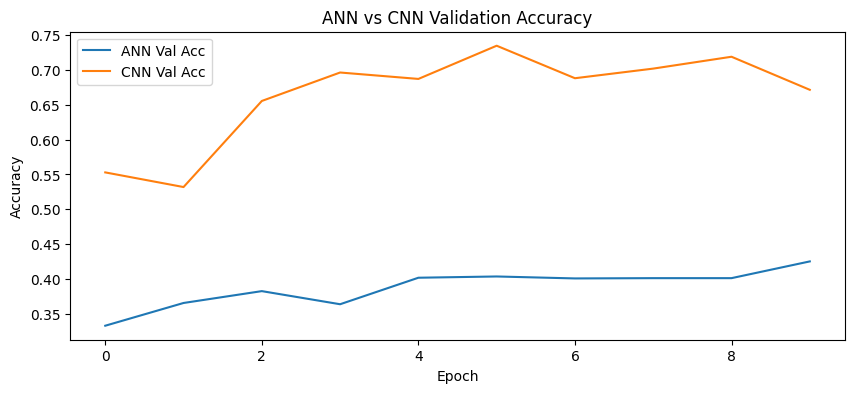

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Quick Comparison Table (Baseline Models)
This is a quick check-in using just the two baseline models trained so far. A **full comparison across every experiment** appears at the bottom of the notebook, after we complete the student tasks below.

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4284
1,CNN,0.6700


# 🎓 Student Learning Tasks — Fully Implemented
Below are the 5 beginner tasks from the intro, each implemented with runnable code so you can see the effect of every change on test accuracy. Every task:

1. Builds/trains its own model (kept separate from the baseline `ann_model` / `cnn_model` so you can still compare against the originals)
2. Prints its test accuracy next to the relevant baseline for an easy comparison

> ⏱️ Note: several of these cells train additional models, so this section will take noticeably longer to run than the sections above. Feel free to lower `epochs` while experimenting.

## ✅ Task 1 — Increase ANN layers and observe performance
We add extra `Dense` layers (and a second `Dropout`) to the ANN to give it more capacity, then compare it against the original single-hidden-layer-ish baseline. Because ANN still only sees a flattened pixel vector, expect the gain to be modest compared to what CNNs achieve.

In [12]:
# Task 1: Increase ANN layers and observe performance
deeper_ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

deeper_ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deeper_ann_history = deeper_ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

deeper_ann_test_loss, deeper_ann_test_acc = deeper_ann_model.evaluate(x_test_flat, y_test)
print("Deeper ANN Test Accuracy:", deeper_ann_test_acc)
print("Baseline ANN Test Accuracy:", ann_test_acc)
print("Change vs baseline ANN:", deeper_ann_test_acc - ann_test_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 61ms/step - accuracy: 0.2498 - loss: 2.0217 - val_accuracy: 0.3160 - val_loss: 1.8882
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 62ms/step - accuracy: 0.3114 - loss: 1.8780 - val_accuracy: 0.3378 - val_loss: 1.8237
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 61ms/step - accuracy: 0.3312 - loss: 1.8278 - val_accuracy: 0.3484 - val_loss: 1.7850
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.3441 - loss: 1.7944 - val_accuracy: 0.3844 - val_loss: 1.7541
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 61ms/step - accuracy: 0.3515 - loss: 1.7782 - val_accuracy: 0.3940 - val_loss: 1.7054
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 63ms/step - accuracy: 0.3627 - loss: 1.7510 - val_accuracy: 0.4092 - val_loss: 1.6707
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.3690 - loss: 1.7330 - val_accuracy: 0.4042 - val_loss: 1.6950
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 62ms/step - accuracy: 0.3797 - loss: 1.7145 - 

## ✅ Task 2 — Scale up CNN filters (32→64→128 and beyond)
The baseline CNN already uses a 32→64→128 filter progression. To directly observe the effect of *scaling filters up further*, we build a wider variant using 64→128→256 filters and compare test accuracy and parameter count against the baseline.

In [13]:
# Task 2: Scale up CNN filters (compare wider filters: 64 -> 128 -> 256 vs baseline 32 -> 64 -> 128)
wide_cnn_model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

wide_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

wide_cnn_history = wide_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

wide_cnn_test_loss, wide_cnn_test_acc = wide_cnn_model.evaluate(x_test_norm, y_test)
print("Wide CNN (64->128->256) Test Accuracy:", wide_cnn_test_acc)
print("Baseline CNN (32->64->128) Test Accuracy:", cnn_test_acc)
print("Params - wide:", wide_cnn_model.count_params(), " baseline:", cnn_model.count_params())


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 207s 291ms/step - accuracy: 0.4436 - loss: 1.5525 - val_accuracy: 0.4398 - val_loss: 1.6045
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 265s 296ms/step - accuracy: 0.5971 - loss: 1.1613 - val_accuracy: 0.5802 - val_loss: 1.1771
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 206s 293ms/step - accuracy: 0.6680 - loss: 0.9693 - val_accuracy: 0.6550 - val_loss: 0.9863
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 265s 297ms/step - accuracy: 0.7167 - loss: 0.8179 - val_accuracy: 0.7114 - val_loss: 0.8480
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 207s 295ms/step - accuracy: 0.7509 - loss: 0.7155 - val_accuracy: 0.6778 - val_loss: 0.9462
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 206s 292ms/step - accuracy: 0.7852 - loss: 0.6211 - val_accuracy: 0.7428 - val_loss: 0.7618
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 205s 291ms/step - accuracy: 0.8170 - loss: 0.5210 - val_accuracy: 0.6906 - val_loss: 0.9718
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 212s 301ms/step - accuracy: 0.8370 -

## ✅ Task 3 — Increase epochs to 20
We retrain a fresh copy of the baseline CNN architecture for 20 epochs instead of 10, to see whether extra training time keeps improving validation accuracy or whether it plateaus/overfits.

In [14]:
# Task 3: Increase training epochs to 20
cnn_20ep_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_20ep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_20ep_history = cnn_20ep_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

cnn_20ep_test_loss, cnn_20ep_test_acc = cnn_20ep_model.evaluate(x_test_norm, y_test)
print("CNN trained for 20 epochs - Test Accuracy:", cnn_20ep_test_acc)
print("CNN trained for 10 epochs (baseline) - Test Accuracy:", cnn_test_acc)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 116ms/step - accuracy: 0.4622 - loss: 1.5030 - val_accuracy: 0.5224 - val_loss: 1.3467
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 114ms/step - accuracy: 0.6076 - loss: 1.1208 - val_accuracy: 0.5896 - val_loss: 1.1642
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.6721 - loss: 0.9479 - val_accuracy: 0.5870 - val_loss: 1.2109
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 113ms/step - accuracy: 0.7109 - loss: 0.8299 - val_accuracy: 0.6866 - val_loss: 0.9490
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.7439 - loss: 0.7337 - val_accuracy: 0.6608 - val_loss: 1.0208
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 114ms/step - accuracy: 0.7669 - loss: 0.6617 - val_accuracy: 0.6882 - val_loss: 0.9444
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 113ms/step - accuracy: 0.7907 - loss: 0.5868 - val_accuracy: 0.6806 - val_loss: 0.9644
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 113ms/step - accuracy: 0.8117 - loss: 0

## ✅ Task 4 — Add EarlyStopping
We train the same CNN architecture for up to 20 epochs, but attach an `EarlyStopping` callback that monitors `val_loss`, stops once it stops improving for 3 epochs in a row, and restores the best weights seen during training.

In [15]:
# Task 4: Add EarlyStopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_es_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_es_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_es_history = cnn_es_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

cnn_es_test_loss, cnn_es_test_acc = cnn_es_model.evaluate(x_test_norm, y_test)
print("CNN + EarlyStopping Test Accuracy:", cnn_es_test_acc)
print("Training stopped after", len(cnn_es_history.history['loss']), "epochs (out of 20 max)")


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 113ms/step - accuracy: 0.4514 - loss: 1.5353 - val_accuracy: 0.5808 - val_loss: 1.1894
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 113ms/step - accuracy: 0.5998 - loss: 1.1384 - val_accuracy: 0.5242 - val_loss: 1.4413
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.6645 - loss: 0.9650 - val_accuracy: 0.5876 - val_loss: 1.1458
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 117ms/step - accuracy: 0.7105 - loss: 0.8322 - val_accuracy: 0.6840 - val_loss: 0.9149
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.7420 - loss: 0.7431 - val_accuracy: 0.6634 - val_loss: 0.9602
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 116ms/step - accuracy: 0.7657 - loss: 0.6673 - val_accuracy: 0.7254 - val_loss: 0.8023
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.7929 - loss: 0.5892 - val_accuracy: 0.6864 - val_loss: 1.0140
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 116ms/step - accuracy: 0.8121 - loss: 0

## ✅ Task 5 — Add data augmentation training
The `aug_cnn_model` was already defined earlier with `RandomFlip`, `RandomRotation`, and `RandomZoom` layers built in. Here we actually run the training (this was left as a commented-out suggestion above) and evaluate it, so we can see whether augmentation improves generalization on the test set.

In [16]:
# Task 5: Train the data-augmented CNN model
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)
print("Baseline CNN Test Accuracy:", cnn_test_acc)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 86ms/step - accuracy: 0.3607 - loss: 1.7449 - val_accuracy: 0.4716 - val_loss: 1.4283
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 83ms/step - accuracy: 0.4599 - loss: 1.4967 - val_accuracy: 0.5394 - val_loss: 1.2762
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 85ms/step - accuracy: 0.5000 - loss: 1.4028 - val_accuracy: 0.5534 - val_loss: 1.2213
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 87ms/step - accuracy: 0.5208 - loss: 1.3389 - val_accuracy: 0.6012 - val_loss: 1.1221
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 86ms/step - accuracy: 0.5395 - loss: 1.3023 - val_accuracy: 0.6146 - val_loss: 1.0864
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 83ms/step - accuracy: 0.5538 - loss: 1.2594 - val_accuracy: 0.6040 - val_loss: 1.1376
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 83ms/step - accuracy: 0.5642 - loss: 1.2347 - val_accuracy: 0.6182 - val_loss: 1.0780
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 83ms/step - accuracy: 0.5712 - loss: 1.2155 - 

# 📊 Extended Final Comparison — All Model Variants
Now that every task has been implemented, here is the complete comparison across the baseline models and all five task variants, sorted from highest to lowest test accuracy.

In [17]:
# Full comparison across baseline models + all 5 task variants
extended_comparison = pd.DataFrame({
    "Model": [
        "ANN (baseline)",
        "CNN (baseline, 32->64->128)",
        "Task 1: Deeper ANN",
        "Task 2: Wide CNN (64->128->256)",
        "Task 3: CNN (20 epochs)",
        "Task 4: CNN + EarlyStopping",
        "Task 5: CNN + Data Augmentation"
    ],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        deeper_ann_test_acc,
        wide_cnn_test_acc,
        cnn_20ep_test_acc,
        cnn_es_test_acc,
        aug_test_acc
    ]
})

extended_comparison = extended_comparison.sort_values(
    "Test Accuracy", ascending=False
).reset_index(drop=True)
extended_comparison


,Model,Test Accuracy
0,Task 2: Wide CNN (64->128->256),0.7326
1,Task 4: CNN + EarlyStopping,0.7191
2,Task 3: CNN (20 epochs),0.7071
3,"CNN (baseline, 32->64->128)",0.6700
4,Task 5: CNN + Data Augmentation,0.6581
5,ANN (baseline),0.4284
6,Task 1: Deeper ANN,0.4253


## 📈 Validation Accuracy — All Variants
A single chart overlaying every experiment's validation accuracy curve makes it easy to see which changes helped the most.

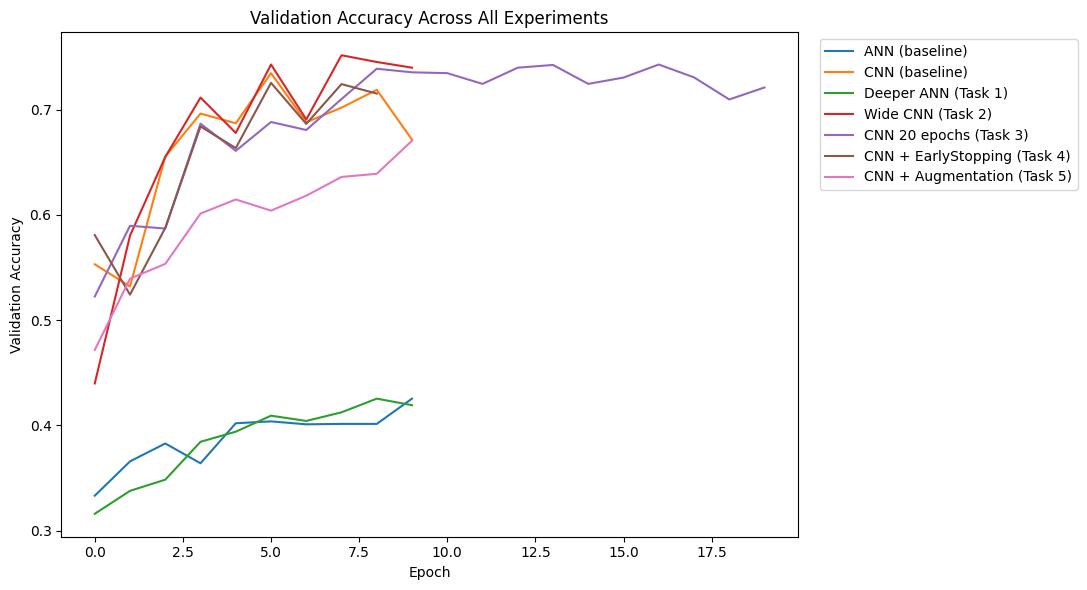

In [18]:
# Overlay validation accuracy curves for every experiment
plt.figure(figsize=(11,6))
plt.plot(ann_history.history['val_accuracy'], label='ANN (baseline)')
plt.plot(cnn_history.history['val_accuracy'], label='CNN (baseline)')
plt.plot(deeper_ann_history.history['val_accuracy'], label='Deeper ANN (Task 1)')
plt.plot(wide_cnn_history.history['val_accuracy'], label='Wide CNN (Task 2)')
plt.plot(cnn_20ep_history.history['val_accuracy'], label='CNN 20 epochs (Task 3)')
plt.plot(cnn_es_history.history['val_accuracy'], label='CNN + EarlyStopping (Task 4)')
plt.plot(aug_history.history['val_accuracy'], label='CNN + Augmentation (Task 5)')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Across All Experiments")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**